# Mean Shift (Сдвиг среднего)

## Теория

Mean Shift — это **непараметрический** алгоритм кластеризации, основанный на **оценке плотности ядром** (Kernel Density Estimation, KDE). В отличие от K-Means, он не требует заранее задавать число кластеров — алгоритм сам находит их, отыскивая **моды** (локальные максимумы) функции плотности.

### Алгоритм

Для каждой точки $x$:
1. Определить окрестность радиуса $h$ (bandwidth) вокруг текущего положения точки.
2. Сдвинуть точку в направлении взвешенного среднего соседей (правило обновления):

$$x^{(t+1)} = \frac{\sum_{x_i \in N(x)} K(x_i - x^{(t)}) \cdot x_i}{\sum_{x_i \in N(x)} K(x_i - x^{(t)})}$$

где $K$ — функция ядра (обычно гауссово), $N(x)$ — множество соседей в окрестности, $h$ — bandwidth.

3. Повторять до сходимости (точка перестаёт смещаться).
4. Точки, сошедшиеся к одному и тому же режиму, образуют один кластер.

### Ключевые гиперпараметры

| Параметр | Значение по умолчанию | Описание |
|---|---|---|
| **bandwidth** | `None` (оценивается автоматически) | Радиус ядра; контролирует гранулярность кластеризации |
| **bin_seeding** | `False` | Если `True` — ускорение за счёт дискретизации начальных точек |
| **cluster_all** | `True` | Если `False` — выбросы (редкие точки) помечаются как кластер −1 |

Параметр **bandwidth** — наиболее важный:
- **Малый bandwidth** → много мелких кластеров (алгоритм видит мелкие локальные пики плотности).
- **Большой bandwidth** → мало крупных кластеров (сглаживание объединяет пики вместе).

Функция `estimate_bandwidth` из `sklearn` автоматически подбирает разумное значение bandwidth на основе квантиля попарных расстояний.

## Датасет

В работе используются два датасета.

### make_blobs — синтетические данные

Генератор `make_blobs` из библиотеки `sklearn` создаёт синтетические 2D-данные с явно выраженными кластерами. Это позволяет наглядно визуализировать работу алгоритма и наблюдать влияние bandwidth на результат кластеризации.

Параметры генерации:
- `n_samples=300` — 300 точек,
- `centers=4` — 4 кластера,
- `cluster_std=0.8` — стандартное отклонение внутри кластера.

### Wine — реальные данные

Датасет **Wine** из библиотеки `sklearn` содержит результаты химического анализа вин из трёх сортов винограда, выращенных в одном регионе Италии.

В датасете:
- **178 объектов** — образцы вин,
- **13 признаков** — результаты химического анализа,
- **3 класса** — три сорта винограда.

### Описание признаков Wine

| Признак | Перевод | Описание |
|---|---|---|
| **alcohol** | алкоголь | содержание алкоголя (%) |
| **malic_acid** | яблочная кислота | концентрация яблочной кислоты |
| **ash** | зола | содержание золы |
| **alcalinity_of_ash** | щёлочность золы | щёлочность золы |
| **magnesium** | магний | содержание магния |
| **total_phenols** | общие фенолы | суммарное содержание фенольных соединений |
| **flavanoids** | флавоноиды | содержание флавоноидов |
| **nonflavanoid_phenols** | нефлавоноидные фенолы | содержание нефлавоноидных фенолов |
| **proanthocyanins** | проантоцианидины | содержание проантоцианидинов |
| **color_intensity** | интенсивность цвета | интенсивность окраски вина |
| **hue** | оттенок | оттенок вина |
| **od280/od315_of_diluted_wines** | OD280/OD315 | оптическая плотность (показатель белка) |
| **proline** | пролин | содержание аминокислоты пролина |

### Описание классов Wine

| Класс | Количество | Особенности |
|---|---|---|
| **class_0** | 59 | высокое содержание алкоголя и пролина |
| **class_1** | 71 | промежуточные значения признаков |
| **class_2** | 48 | низкое содержание флавоноидов |

## Используемые библиотеки

В работе используются `numpy`, `pandas`, `matplotlib` и алгоритмы `sklearn` для кластеризации Mean Shift, оценки `bandwidth` и расчёта метрик качества


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, load_wine
from sklearn.cluster import MeanShift, KMeans, estimate_bandwidth
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


Размер синтетических данных: (300, 2)
Количество точек в каждом кластере: [75 75 75 75]


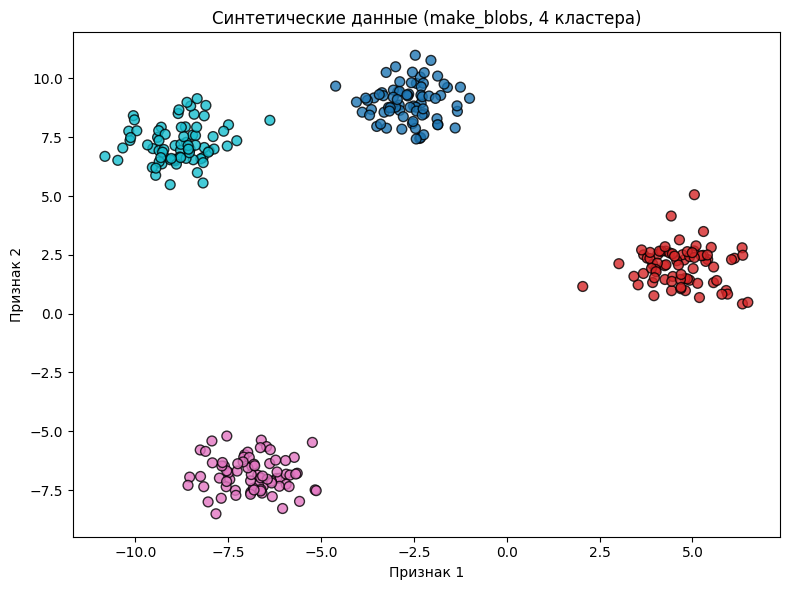

In [3]:
X_blobs, y_blobs = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=0.8,
    random_state=42
)

print("Размер синтетических данных:", X_blobs.shape)
print("Количество точек в каждом кластере:", np.bincount(y_blobs))

plt.figure(figsize=(8, 6))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=y_blobs, cmap='tab10', edgecolor='black', s=50, alpha=0.8)
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.title('Синтетические данные (make_blobs, 4 кластера)')
plt.tight_layout()
plt.show()

In [4]:
wine = load_wine()

X_wine = wine.data
y_wine = wine.target

feature_names = wine.feature_names
target_names = wine.target_names

print("Размер матрицы признаков X:", X_wine.shape)
print("Размер целевой переменной y:", y_wine.shape)
print("\nНазвания признаков:", feature_names)
print("\nНазвания классов:", target_names)

df = pd.DataFrame(X_wine, columns=feature_names)
df["target"] = y_wine

df.head()

Размер матрицы признаков X: (178, 13)
Размер целевой переменной y: (178,)

Названия признаков: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Названия классов: ['class_0' 'class_1' 'class_2']


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


### Базовые статистики датасета

In [5]:
df.describe().round(2)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00
mean,13.00,2.34,2.37,19.49,99.74,2.30,2.03,0.36,1.59,5.06,0.96,2.61,746.89,0.94
std,0.81,1.12,0.27,3.34,14.28,0.63,1.00,0.12,0.57,2.32,0.23,0.71,314.91,0.78
min,11.03,0.74,1.36,10.60,70.00,0.98,0.34,0.13,0.41,1.28,0.48,1.27,278.00,0.00
25%,12.36,1.60,2.21,17.20,88.00,1.74,1.20,0.27,1.25,3.22,0.78,1.94,500.50,0.00
50%,13.05,1.87,2.36,19.50,98.00,2.36,2.13,0.34,1.56,4.69,0.96,2.78,673.50,1.00
75%,13.68,3.08,2.56,21.50,107.00,2.80,2.88,0.44,1.95,6.20,1.12,3.17,985.00,2.00
max,14.83,5.80,3.23,30.00,162.00,3.88,5.08,0.66,3.58,13.00,1.71,4.00,1680.00,2.00


In [6]:
class_counts = pd.Series(y_wine).value_counts().sort_index()

print("Количество объектов каждого класса:")
for class_id, count in class_counts.items():
    print(f"  {target_names[class_id]} ({class_id}): {count}")

Количество объектов каждого класса:
  class_0 (0): 59
  class_1 (1): 71
  class_2 (2): 48


### Сравнение классов по средним значениям признаков

In [7]:
class_means = df.groupby("target")[list(feature_names)].mean().T
class_means.columns = [target_names[int(c)] for c in class_means.columns]
class_means = class_means.round(2)

print("Средние значения признаков по классам:\n")
print(class_means.to_string())

Средние значения признаков по классам:

                              class_0  class_1  class_2
alcohol                         13.74    12.28    13.15
malic_acid                       2.01     1.93     3.33
ash                              2.46     2.24     2.44
alcalinity_of_ash               17.04    20.24    21.42
magnesium                      106.34    94.55    99.31
total_phenols                    2.84     2.26     1.68
flavanoids                       2.98     2.08     0.78
nonflavanoid_phenols             0.29     0.36     0.45
proanthocyanins                  1.90     1.63     1.15
color_intensity                  5.53     3.09     7.40
hue                              1.06     1.06     0.68
od280/od315_of_diluted_wines     3.16     2.79     1.68
proline                       1115.71   519.51   629.90


## Тепловая карта

Строим тепловую карту корреляций между признаками датасета `Wine`


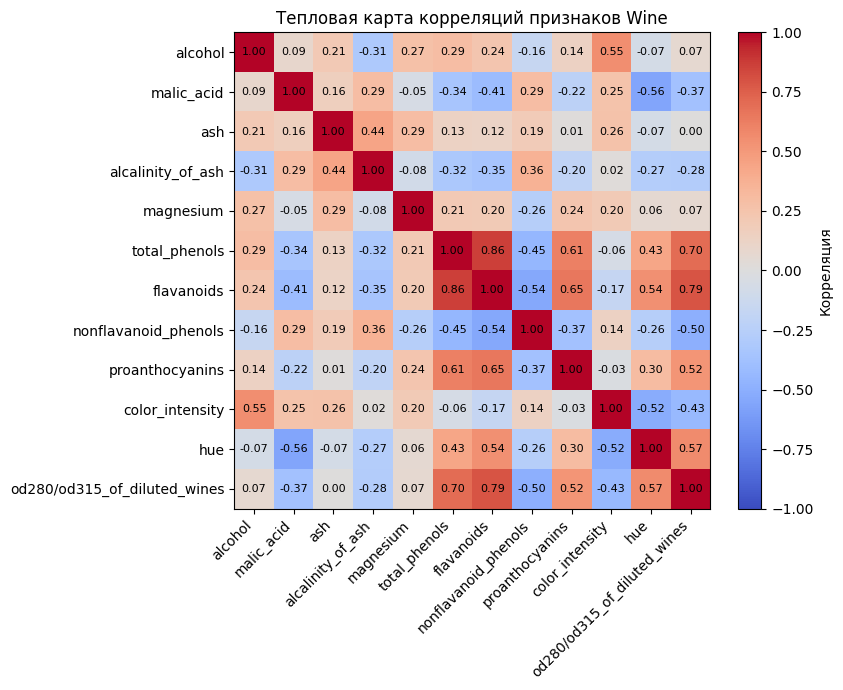

In [8]:
heatmap_features = list(feature_names)
if len(heatmap_features) > 12:
    heatmap_features = heatmap_features[:12]

corr_matrix = df[heatmap_features].corr().round(2)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(heatmap_features)))
ax.set_yticks(range(len(heatmap_features)))
ax.set_xticklabels(heatmap_features, rotation=45, ha='right')
ax.set_yticklabels(heatmap_features)
ax.set_title('Тепловая карта корреляций признаков Wine')

for i in range(len(heatmap_features)):
    for j in range(len(heatmap_features)):
        ax.text(j, i, f"{corr_matrix.values[i, j]:.2f}", ha='center', va='center', color='black', fontsize=8)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Корреляция')
plt.tight_layout()
plt.show()


## Обучение модели

Обучаем Mean Shift сначала на синтетических данных, затем на реальном датасете `Wine` после стандартизации признаков


## Mean Shift на синтетических данных

Применим Mean Shift к синтетическим данным, оценив bandwidth с помощью `estimate_bandwidth`. Визуализируем найденные кластеры и моды плотности.

In [9]:
bw_auto = estimate_bandwidth(X_blobs, quantile=0.2, random_state=42)
print(f"Автоматически оценённый bandwidth: {bw_auto:.4f}")

ms = MeanShift(bandwidth=bw_auto)
ms.fit(X_blobs)

labels_blobs = ms.labels_
cluster_centers = ms.cluster_centers_
n_clusters = len(np.unique(labels_blobs))

print(f"Найдено кластеров: {n_clusters}")
print("Размер каждого кластера:", np.bincount(labels_blobs))

Автоматически оценённый bandwidth: 1.8856


Найдено кластеров: 4
Размер каждого кластера: [75 75 75 75]


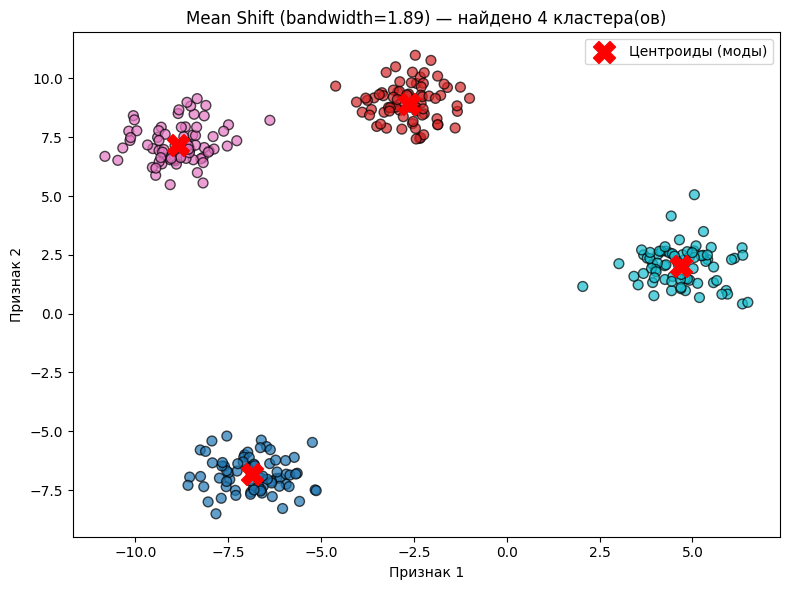

In [10]:
plt.figure(figsize=(8, 6))
plt.scatter(
    X_blobs[:, 0], X_blobs[:, 1],
    c=labels_blobs, cmap='tab10', edgecolor='black', s=50, alpha=0.7
)
plt.scatter(
    cluster_centers[:, 0], cluster_centers[:, 1],
    c='red', marker='X', s=250, zorder=5, label='Центроиды (моды)'
)
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.title(f'Mean Shift (bandwidth={bw_auto:.2f}) — найдено {n_clusters} кластера(ов)')
plt.legend()
plt.tight_layout()
plt.show()

## Влияние параметра bandwidth

Исследуем, как значение bandwidth влияет на число найденных кластеров: малый bandwidth даёт много кластеров, большой — мало.

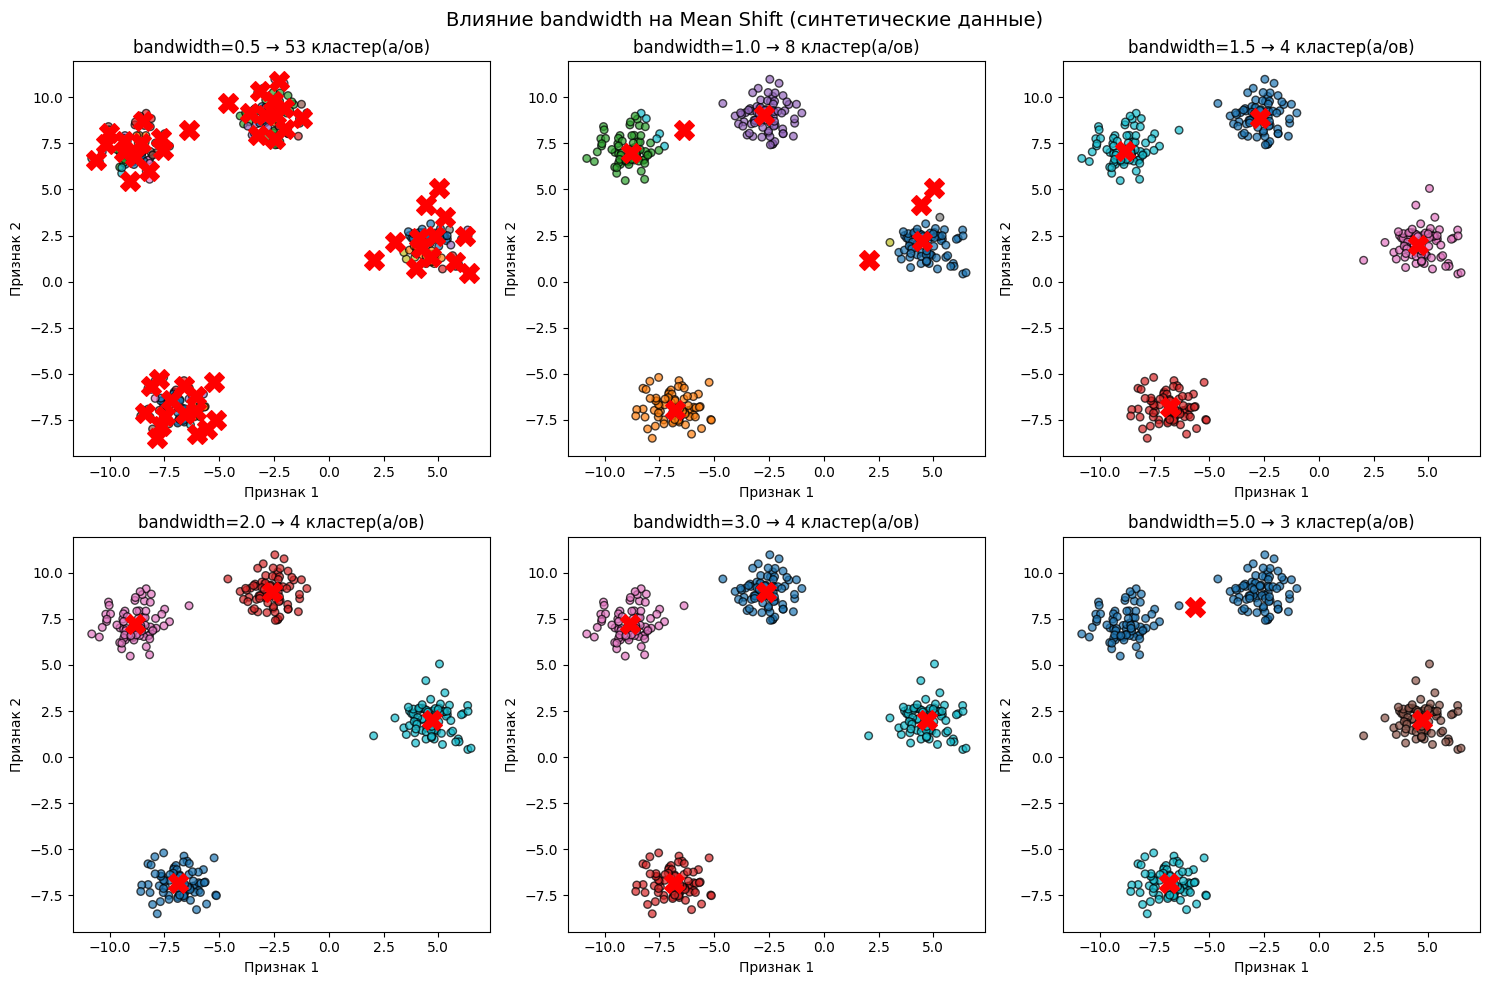

Итог по числу кластеров:
  bandwidth=0.5: 53 кластер(а/ов)


  bandwidth=1.0: 8 кластер(а/ов)
  bandwidth=1.5: 4 кластер(а/ов)


  bandwidth=2.0: 4 кластер(а/ов)
  bandwidth=3.0: 4 кластер(а/ов)
  bandwidth=5.0: 3 кластер(а/ов)


In [11]:
bandwidths = [0.5, 1.0, 1.5, 2.0, 3.0, 5.0]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, bw in enumerate(bandwidths):
    ms_bw = MeanShift(bandwidth=bw)
    ms_bw.fit(X_blobs)
    labels_bw = ms_bw.labels_
    centers_bw = ms_bw.cluster_centers_
    n_cl = len(np.unique(labels_bw))

    axes[idx].scatter(
        X_blobs[:, 0], X_blobs[:, 1],
        c=labels_bw, cmap='tab10', edgecolor='black', s=30, alpha=0.7
    )
    axes[idx].scatter(
        centers_bw[:, 0], centers_bw[:, 1],
        c='red', marker='X', s=200, zorder=5
    )
    axes[idx].set_title(f'bandwidth={bw} → {n_cl} кластер(а/ов)')
    axes[idx].set_xlabel('Признак 1')
    axes[idx].set_ylabel('Признак 2')

plt.suptitle('Влияние bandwidth на Mean Shift (синтетические данные)', fontsize=14)
plt.tight_layout()
plt.show()

print("Итог по числу кластеров:")
for bw in bandwidths:
    ms_tmp = MeanShift(bandwidth=bw)
    ms_tmp.fit(X_blobs)
    print(f"  bandwidth={bw:.1f}: {len(np.unique(ms_tmp.labels_))} кластер(а/ов)")

## Сравнение с K-Means на синтетических данных

Сравним Mean Shift с K-Means на одних и тех же синтетических данных. K-Means требует явно задать `n_clusters=4`, тогда как Mean Shift находит число кластеров автоматически.

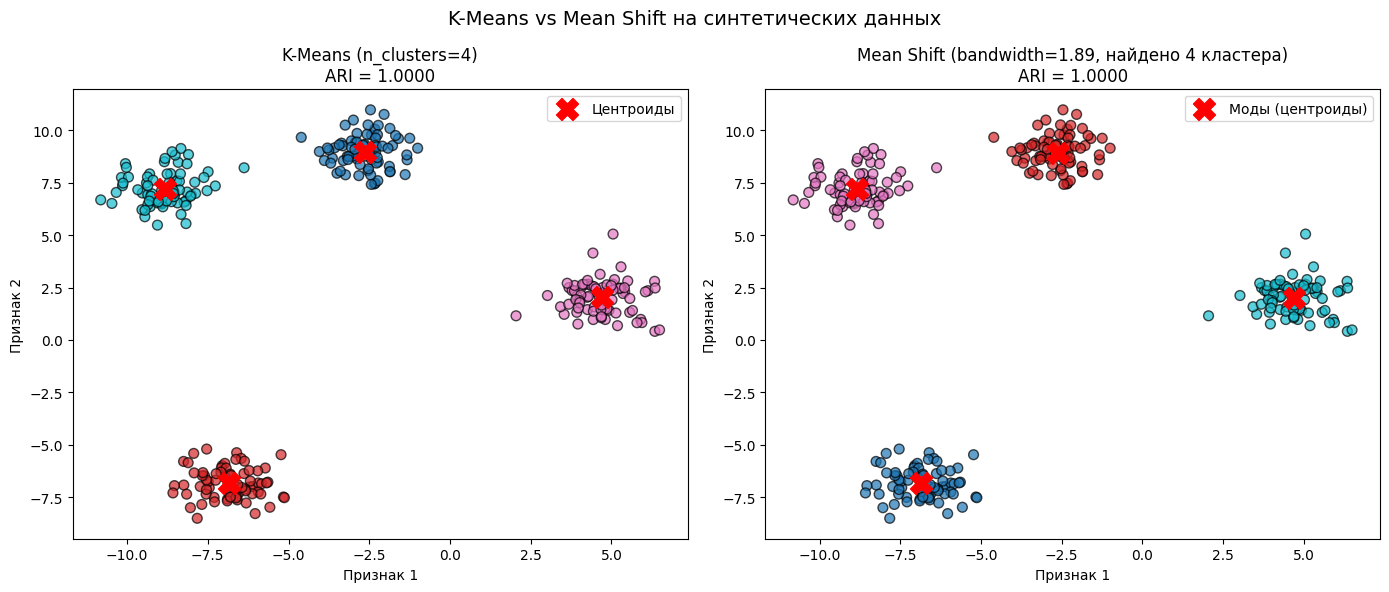

ARI K-Means:    1.0000
ARI Mean Shift: 1.0000


In [12]:
kmeans = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42)
kmeans.fit(X_blobs)
labels_km = kmeans.labels_
centers_km = kmeans.cluster_centers_

ms_compare = MeanShift(bandwidth=bw_auto)
ms_compare.fit(X_blobs)
labels_ms = ms_compare.labels_
centers_ms = ms_compare.cluster_centers_

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(
    X_blobs[:, 0], X_blobs[:, 1],
    c=labels_km, cmap='tab10', edgecolor='black', s=50, alpha=0.7
)
axes[0].scatter(
    centers_km[:, 0], centers_km[:, 1],
    c='red', marker='X', s=250, zorder=5, label='Центроиды'
)
axes[0].set_xlabel('Признак 1')
axes[0].set_ylabel('Признак 2')
axes[0].set_title(f'K-Means (n_clusters=4)\nARI = {adjusted_rand_score(y_blobs, labels_km):.4f}')
axes[0].legend()

axes[1].scatter(
    X_blobs[:, 0], X_blobs[:, 1],
    c=labels_ms, cmap='tab10', edgecolor='black', s=50, alpha=0.7
)
axes[1].scatter(
    centers_ms[:, 0], centers_ms[:, 1],
    c='red', marker='X', s=250, zorder=5, label='Моды (центроиды)'
)
axes[1].set_xlabel('Признак 1')
axes[1].set_ylabel('Признак 2')
axes[1].set_title(f'Mean Shift (bandwidth={bw_auto:.2f}, найдено {len(np.unique(labels_ms))} кластера)\nARI = {adjusted_rand_score(y_blobs, labels_ms):.4f}')
axes[1].legend()

plt.suptitle('K-Means vs Mean Shift на синтетических данных', fontsize=14)
plt.tight_layout()
plt.show()

print(f"ARI K-Means:    {adjusted_rand_score(y_blobs, labels_km):.4f}")
print(f"ARI Mean Shift: {adjusted_rand_score(y_blobs, labels_ms):.4f}")

## Mean Shift на датасете Wine

Применим Mean Shift к реальным данным Wine. Используем `StandardScaler` перед кластеризацией и сравним найденные кластеры с истинными метками классов.

In [13]:
scaler = StandardScaler()
X_wine_scaled = scaler.fit_transform(X_wine)

bw_wine = estimate_bandwidth(X_wine_scaled, quantile=0.2, random_state=42)
print(f"Автоматически оценённый bandwidth (Wine, scaled): {bw_wine:.4f}")

ms_wine = MeanShift(bandwidth=bw_wine)
ms_wine.fit(X_wine_scaled)

labels_wine = ms_wine.labels_
n_clusters_wine = len(np.unique(labels_wine))

print(f"Найдено кластеров: {n_clusters_wine} (истинных классов: 3)")
print("Размер каждого кластера:", np.bincount(labels_wine))

ari_wine = adjusted_rand_score(y_wine, labels_wine)
print(f"\nAdjusted Rand Index (ARI): {ari_wine:.4f}")
print("(ARI=1.0 — идеальное совпадение, ARI=0 — случайное)")

Автоматически оценённый bandwidth (Wine, scaled): 3.5511
Найдено кластеров: 6 (истинных классов: 3)
Размер каждого кластера: [102  68   3   1   2   2]

Adjusted Rand Index (ARI): 0.3643
(ARI=1.0 — идеальное совпадение, ARI=0 — случайное)


## Метод локтя

Для Mean Shift количество кластеров определяется автоматически, поэтому в качестве аналога метода локтя анализируем, как меняется число кластеров при изменении `bandwidth`


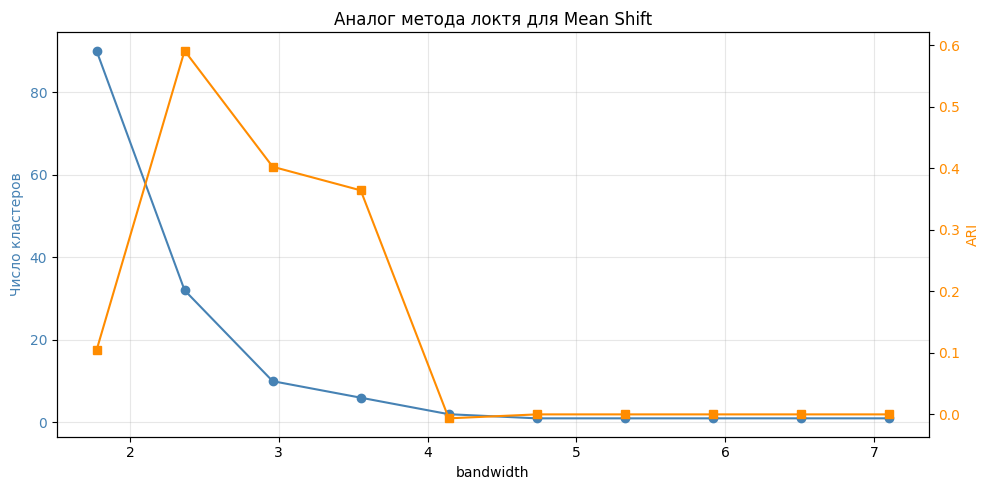

In [14]:
bandwidth_grid = np.linspace(max(0.4, bw_wine * 0.5), bw_wine * 2.0, 10)
cluster_counts = []
ari_scores = []

for bw in bandwidth_grid:
    labels_bw = MeanShift(bandwidth=float(bw)).fit_predict(X_wine_scaled)
    cluster_counts.append(len(np.unique(labels_bw)))
    ari_scores.append(adjusted_rand_score(y_wine, labels_bw))

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(bandwidth_grid, cluster_counts, marker='o', color='steelblue')
ax1.set_xlabel('bandwidth')
ax1.set_ylabel('Число кластеров', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(bandwidth_grid, ari_scores, marker='s', color='darkorange')
ax2.set_ylabel('ARI', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

plt.title('Аналог метода локтя для Mean Shift')
plt.tight_layout()
plt.show()


## Метод силуэта

Дополнительно оцениваем качество кластеризации Mean Shift по методу силуэта при разных значениях `bandwidth`


Лучший bandwidth по silhouette: 4.1429
Лучший silhouette score:       0.2245


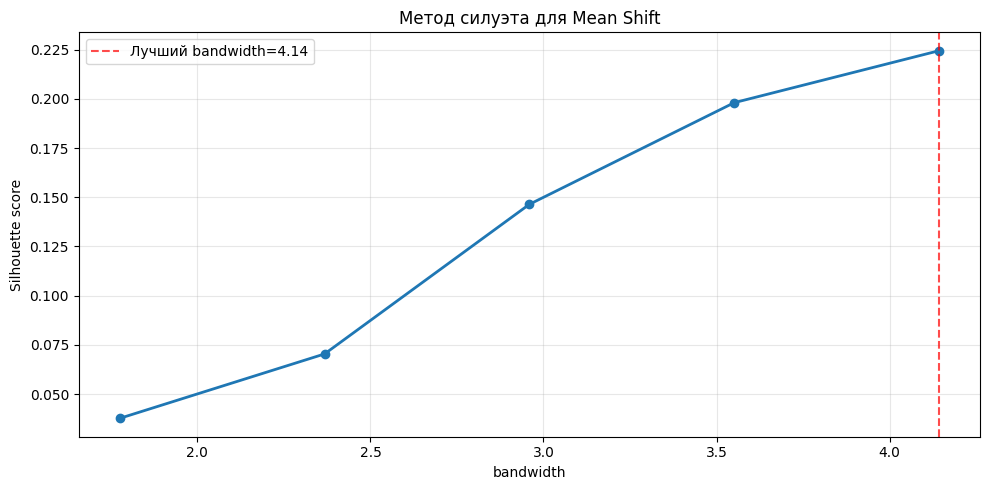

In [15]:
silhouette_bandwidths = []
silhouette_scores = []

for bw in bandwidth_grid:
    labels_bw = MeanShift(bandwidth=float(bw)).fit_predict(X_wine_scaled)
    if len(set(labels_bw)) >= 2:
        silhouette_bandwidths.append(float(bw))
        silhouette_scores.append(silhouette_score(X_wine_scaled, labels_bw))

if silhouette_bandwidths:
    best_idx = int(np.argmax(silhouette_scores))
    print(f'Лучший bandwidth по silhouette: {silhouette_bandwidths[best_idx]:.4f}')
    print(f'Лучший silhouette score:       {silhouette_scores[best_idx]:.4f}')

    plt.figure(figsize=(10, 5))
    plt.plot(silhouette_bandwidths, silhouette_scores, marker='o', linewidth=2)
    plt.axvline(silhouette_bandwidths[best_idx], color='red', linestyle='--', alpha=0.7, label=f'Лучший bandwidth={silhouette_bandwidths[best_idx]:.2f}')
    plt.xlabel('bandwidth')
    plt.ylabel('Silhouette score')
    plt.title('Метод силуэта для Mean Shift')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


## Прогнозы модели

Анализируем предсказанные кластерные метки Mean Shift и сравниваем их с истинными классами `Wine`


In [16]:
print('Первые 20 меток Mean Shift для Wine:')
print(labels_wine[:20])


Первые 20 меток Mean Shift для Wine:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [17]:
print("Таблица соответствия (истинный класс → кластер Mean Shift):")
comparison_wine = pd.crosstab(
    pd.Series(y_wine, name='Истинный класс').map(dict(enumerate(target_names))),
    pd.Series(labels_wine, name='Кластер Mean Shift')
)
print(comparison_wine)

Таблица соответствия (истинный класс → кластер Mean Shift):
Кластер Mean Shift   0   1  2  3  4  5
Истинный класс                        
class_0             58   0  0  0  0  1
class_1             44  20  3  1  2  1
class_2              0  48  0  0  0  0


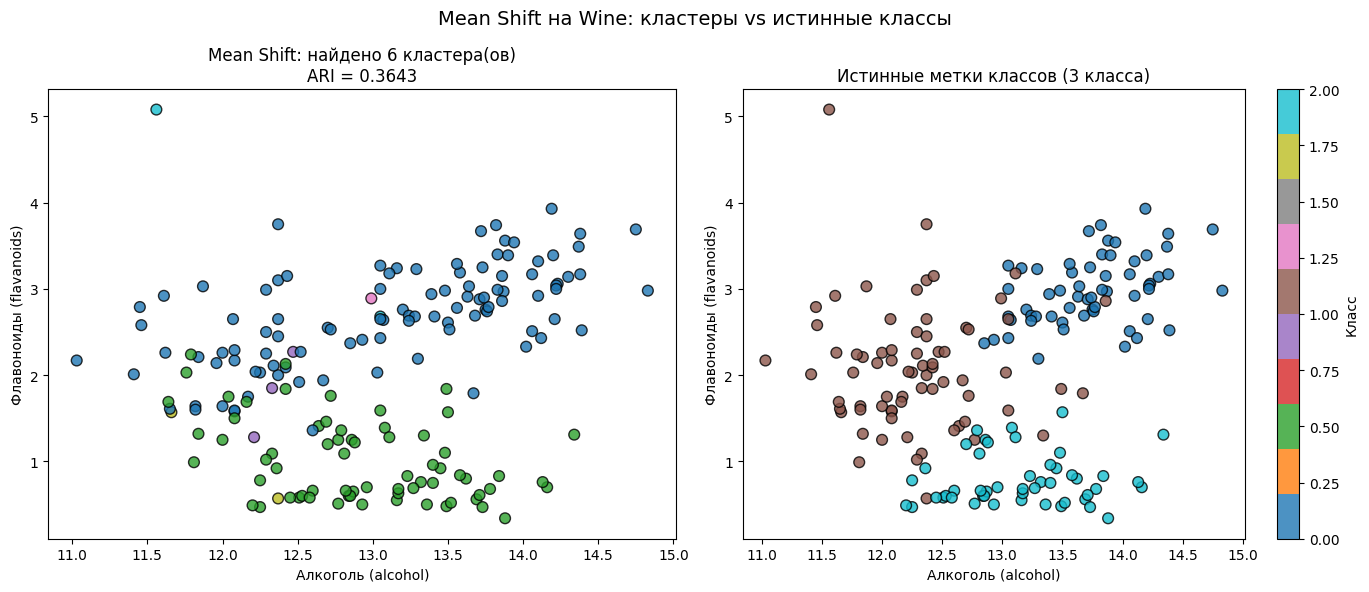

In [18]:
idx_alc = list(feature_names).index('alcohol')
idx_flav = list(feature_names).index('flavanoids')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(
    X_wine[:, idx_alc], X_wine[:, idx_flav],
    c=labels_wine, cmap='tab10', edgecolor='black', s=60, alpha=0.8
)
axes[0].set_xlabel('Алкоголь (alcohol)')
axes[0].set_ylabel('Флавоноиды (flavanoids)')
axes[0].set_title(f'Mean Shift: найдено {n_clusters_wine} кластера(ов)\nARI = {ari_wine:.4f}')

scatter = axes[1].scatter(
    X_wine[:, idx_alc], X_wine[:, idx_flav],
    c=y_wine, cmap='tab10', edgecolor='black', s=60, alpha=0.8
)
axes[1].set_xlabel('Алкоголь (alcohol)')
axes[1].set_ylabel('Флавоноиды (flavanoids)')
axes[1].set_title('Истинные метки классов (3 класса)')
plt.colorbar(scatter, ax=axes[1], label='Класс')

plt.suptitle('Mean Shift на Wine: кластеры vs истинные классы', fontsize=14)
plt.tight_layout()
plt.show()

## Влияние масштабирования

Сравним результаты Mean Shift на Wine с `StandardScaler` и без него.

Сравнение результатов (датасет Wine):
  Без масштабирования:  bandwidth=125.6393, кластеров=5, ARI=0.3363
  С масштабированием:   bandwidth=3.5511, кластеров=6, ARI=0.3643


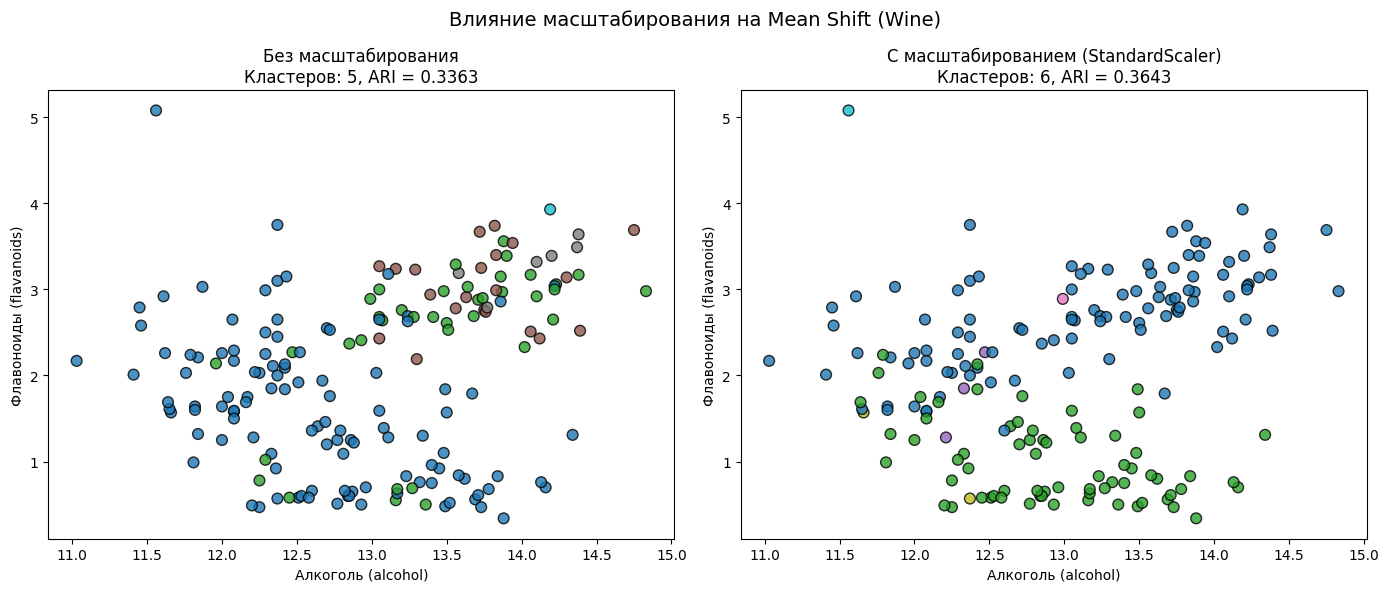

In [19]:
bw_noscale = estimate_bandwidth(X_wine, quantile=0.2, random_state=42)
ms_noscale = MeanShift(bandwidth=bw_noscale)
ms_noscale.fit(X_wine)
labels_noscale = ms_noscale.labels_
n_cl_noscale = len(np.unique(labels_noscale))
ari_noscale = adjusted_rand_score(y_wine, labels_noscale)

n_cl_scaled = n_clusters_wine
ari_scaled = ari_wine

print("Сравнение результатов (датасет Wine):")
print(f"  Без масштабирования:  bandwidth={bw_noscale:.4f}, кластеров={n_cl_noscale}, ARI={ari_noscale:.4f}")
print(f"  С масштабированием:   bandwidth={bw_wine:.4f}, кластеров={n_cl_scaled}, ARI={ari_scaled:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(
    X_wine[:, idx_alc], X_wine[:, idx_flav],
    c=labels_noscale, cmap='tab10', edgecolor='black', s=60, alpha=0.8
)
axes[0].set_xlabel('Алкоголь (alcohol)')
axes[0].set_ylabel('Флавоноиды (flavanoids)')
axes[0].set_title(f'Без масштабирования\nКластеров: {n_cl_noscale}, ARI = {ari_noscale:.4f}')

axes[1].scatter(
    X_wine[:, idx_alc], X_wine[:, idx_flav],
    c=labels_wine, cmap='tab10', edgecolor='black', s=60, alpha=0.8
)
axes[1].set_xlabel('Алкоголь (alcohol)')
axes[1].set_ylabel('Флавоноиды (flavanoids)')
axes[1].set_title(f'С масштабированием (StandardScaler)\nКластеров: {n_cl_scaled}, ARI = {ari_scaled:.4f}')

plt.suptitle('Влияние масштабирования на Mean Shift (Wine)', fontsize=14)
plt.tight_layout()
plt.show()

## Автоматический подбор bandwidth

Исследуем влияние параметра `quantile` в `estimate_bandwidth` на оценённый bandwidth и итоговое число кластеров.

In [20]:
quantiles = [0.1, 0.2, 0.3, 0.5]

print("Влияние quantile на estimate_bandwidth и число кластеров (Wine, scaled):\n")
print(f"{'quantile':>10}  {'bandwidth':>12}  {'кластеров':>12}  {'ARI':>8}")
print("-" * 50)

for q in quantiles:
    bw_q = estimate_bandwidth(X_wine_scaled, quantile=q, random_state=42)
    ms_q = MeanShift(bandwidth=bw_q)
    ms_q.fit(X_wine_scaled)
    labels_q = ms_q.labels_
    n_cl_q = len(np.unique(labels_q))
    ari_q = adjusted_rand_score(y_wine, labels_q)
    print(f"{q:>10.1f}  {bw_q:>12.4f}  {n_cl_q:>12}  {ari_q:>8.4f}")

print("\nВывод: малый quantile даёт малый bandwidth и много кластеров,")
print("       большой quantile — большой bandwidth и мало кластеров.")

Влияние quantile на estimate_bandwidth и число кластеров (Wine, scaled):

  quantile     bandwidth     кластеров       ARI
--------------------------------------------------
       0.1        3.0032            10    0.4010


       0.2        3.5511             6    0.3643
       0.3        4.0933             2   -0.0064


       0.5        5.0375             1    0.0000

Вывод: малый quantile даёт малый bandwidth и много кластеров,
       большой quantile — большой bandwidth и мало кластеров.


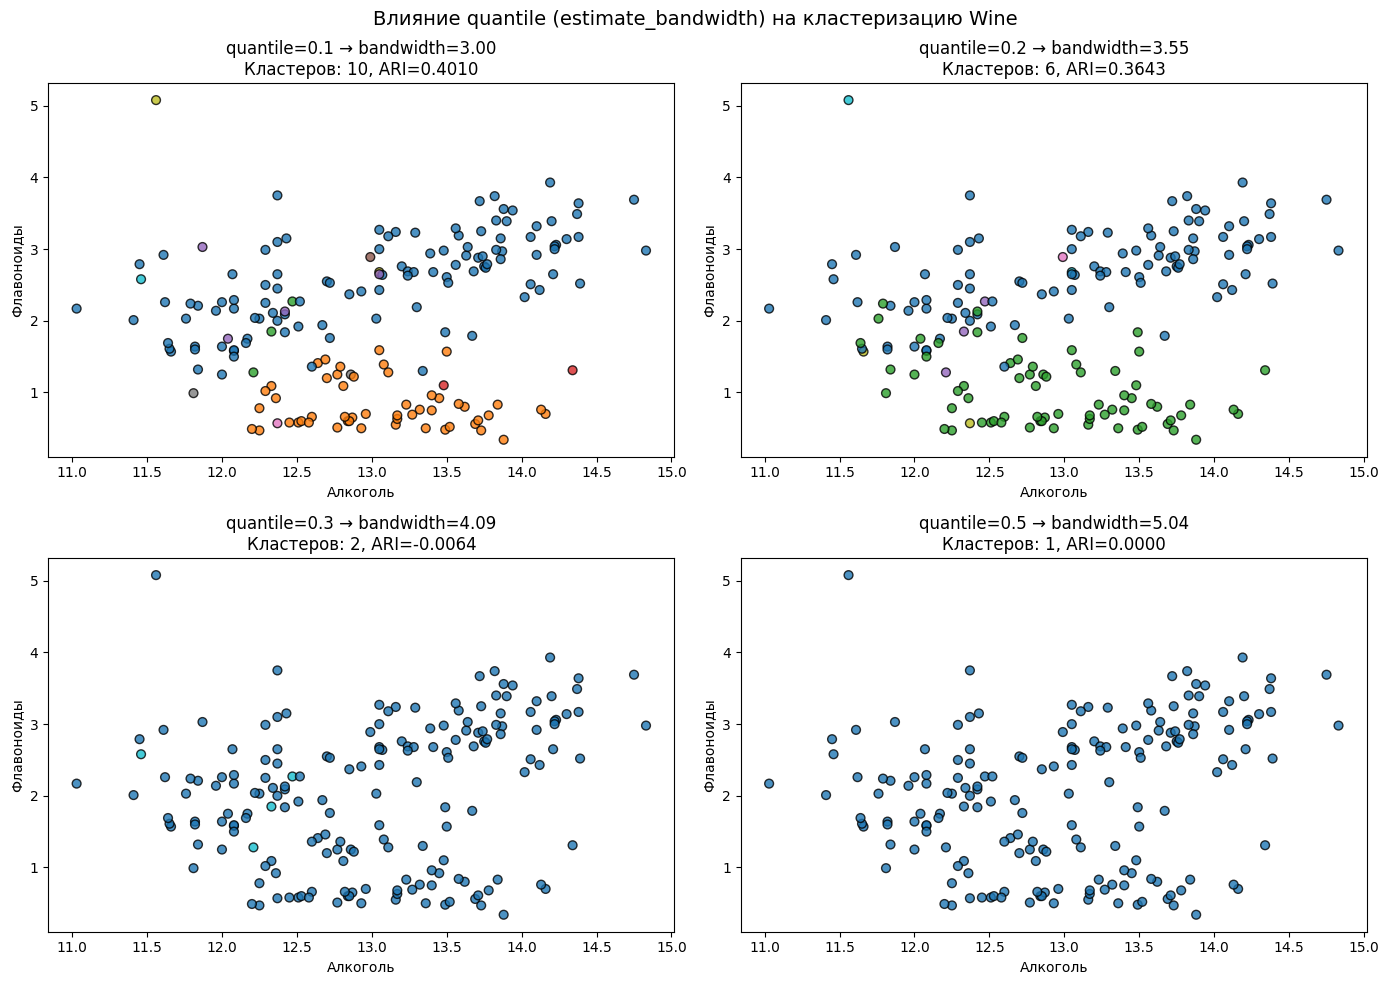

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, q in enumerate(quantiles):
    bw_q = estimate_bandwidth(X_wine_scaled, quantile=q, random_state=42)
    ms_q = MeanShift(bandwidth=bw_q)
    ms_q.fit(X_wine_scaled)
    labels_q = ms_q.labels_
    n_cl_q = len(np.unique(labels_q))
    ari_q = adjusted_rand_score(y_wine, labels_q)

    axes[idx].scatter(
        X_wine[:, idx_alc], X_wine[:, idx_flav],
        c=labels_q, cmap='tab10', edgecolor='black', s=40, alpha=0.8
    )
    axes[idx].set_xlabel('Алкоголь')
    axes[idx].set_ylabel('Флавоноиды')
    axes[idx].set_title(f'quantile={q} → bandwidth={bw_q:.2f}\nКластеров: {n_cl_q}, ARI={ari_q:.4f}')

plt.suptitle('Влияние quantile (estimate_bandwidth) на кластеризацию Wine', fontsize=14)
plt.tight_layout()
plt.show()